## Import libraries, load, analyse and transform data

In [1]:
import pathlib
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

In [2]:
train_folder = pathlib.Path("..") / "assets" / "simulated_dataset" / "train"

train_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in train_folder.glob("*.csv")
}

list(train_dataframes.keys())

['tbm_failure_logs_combined_train',
 'tbm_ts_truck_brake_train',
 'tbm_ts_truck_tire_train',
 'tbm_ts_van_brake_train',
 'tbm_ts_van_tire_train']

In [3]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
for name, df in train_dataframes.items():
	print(f"{name}:")
	print(df.head())
	print("-" * 120)

tbm_failure_logs_combined_train:
   machine_id  failure_time  region  route       speed      load failure_type car_type  route_ratio
0           1          37.0     2.0    0.0  103.462715  0.633820        Tires   Trucks    10.904762
1           1          46.0     2.0    0.0   98.352409  0.555570        Tires   Trucks    10.904762
2           1          67.0     2.0    0.0  102.767014  0.519141        Tires   Trucks    10.904762
3           1          94.0     2.0    0.0  102.561248  0.642696        Tires   Trucks    10.904762
4           1          98.0     2.0    0.0  109.632201  0.636569       Brakes   Trucks    10.904762
------------------------------------------------------------------------------------------------------------------------
tbm_ts_truck_brake_train:
   machine_id  time car_type  region  route  route_ratio       speed      load  failure_occurred failure_type
0           1   0.0   Trucks       2      0    10.904762  106.526257  0.494003                 0          NaN


In [4]:
# how many data points do we have in each dataframe?
for df_name, df in train_dataframes.items():
    print(f"{df_name}: {len(df)} rows")

tbm_failure_logs_combined_train: 13072 rows
tbm_ts_truck_brake_train: 170000 rows
tbm_ts_truck_tire_train: 170000 rows
tbm_ts_van_brake_train: 170000 rows
tbm_ts_van_tire_train: 170000 rows


In [5]:
# lets focus on trucks and brakes first
truck_brake_df = train_dataframes['tbm_ts_truck_brake_train'].copy()

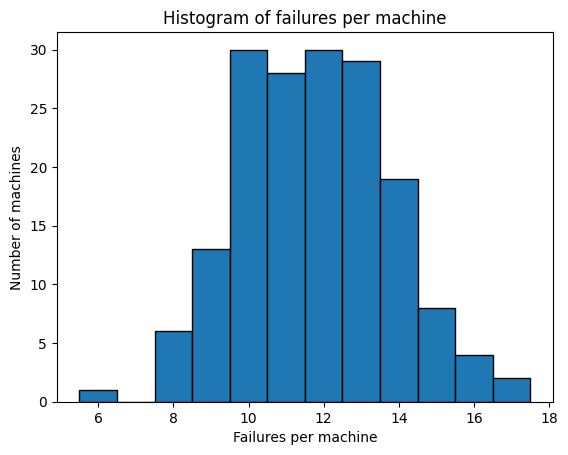

In [6]:
# number of failures per machine histogram
failures_per_machine = (
    truck_brake_df.groupby("machine_id")["failure_occurred"]
    .sum()
    .astype(int)
    .rename("failure_count")
)

ax = failures_per_machine.plot.hist(
    bins=np.arange(failures_per_machine.min() - 0.5, failures_per_machine.max() + 1.5, 1),
    edgecolor="black"
)
ax.set_xlabel("Failures per machine")
ax.set_ylabel("Number of machines")
ax.set_title("Histogram of failures per machine")
plt.show()

In [7]:
# transform dataframe from time-based to event-based (one row per failure)
failure_rows = []

tb_sorted = truck_brake_df.sort_values(["machine_id", "time"])

for machine_id, g in tb_sorted.groupby("machine_id", sort=False):
    g = g.reset_index(drop=True)
    failure_pos = np.flatnonzero(g["failure_occurred"].to_numpy() == 1)

    for k, pos in enumerate(failure_pos):
        prev_pos = None if k == 0 else failure_pos[k - 1]
        start = 0 if prev_pos is None else prev_pos + 1
        seg = g.iloc[start : pos + 1]

        route_frac = seg["route"].value_counts(normalize=True)
        t_curr = g.at[pos, "time"]
        t_prev = g.at[prev_pos, "time"] if prev_pos is not None else 0.0

        failure_rows.append(
            {
                "machine_id": machine_id,
                "failure_time": float(t_curr - t_prev),
                "route_frac_HW": float(route_frac.get(0, 0.0)),
                "route_frac_city": float(route_frac.get(1, 0.0)),
                "region": g.at[pos, "region"],
                "avg_speed": float(seg["speed"].mean()),
                "avg_load": float(seg["load"].mean()),
                "last_speed": g.at[pos, "speed"], 
                "last_load": g.at[pos, "load"],
            }
        )

failure_summary_df = pd.DataFrame(failure_rows)
failure_summary_df.head()

,machine_id,failure_time,route_frac_HW,route_frac_city,region,avg_speed,avg_load,last_speed,last_load
0,1,98.0,0.929293,0.070707,2,95.851951,0.609040,109.632201,0.636569
1,1,22.0,0.818182,0.181818,2,87.433444,0.627943,89.292895,0.675644
2,1,55.0,0.927273,0.072727,2,95.663184,0.603490,100.288735,0.495554
3,1,71.0,0.845070,0.154930,2,88.529533,0.608592,103.033955,0.665486
4,1,134.0,0.925373,0.074627,2,93.781851,0.604270,117.913995,0.785874


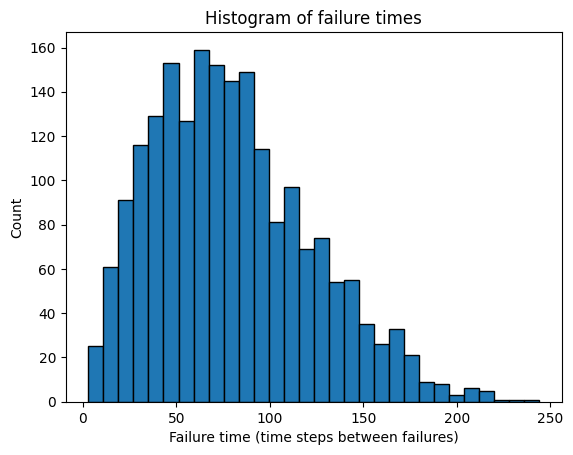

In [8]:
# failure time histogram
ax = failure_summary_df["failure_time"].plot.hist(bins=30, edgecolor="black")
ax.set_xlabel("Failure time (time steps between failures)")
ax.set_ylabel("Count")
ax.set_title("Histogram of failure times")
plt.show()

## Build and train pymc model for failure times

In [9]:
machine_idx, machine_numbers = pd.factorize(failure_summary_df["machine_id"])
machine_idx1 = pd.Series(machine_idx).drop_duplicates().index.to_numpy() # indices of first row for each machine

region = failure_summary_df['region'][machine_idx1].to_numpy() # region for each machine (which appears to be a constant for each machine)
region_numbers = failure_summary_df['region'].unique()

last_speed_mean = failure_summary_df["last_speed"].mean()
last_speed_std = failure_summary_df["last_speed"].std()
last_load_mean = failure_summary_df["last_load"].mean()
last_load_std = failure_summary_df["last_load"].std()

Some explanation on the model below:
* There are long-term and short-term effects of the covariates on the hazard function. Lets call the corresponding covariates $x_\mathrm{L}$ and $x_\mathrm{L}$. In this case, we consider the region and route ratio (or fractions of highway vs city traffic) to have a long-term effect, speed and load have a short-term effect.
* In general, given a hazard function $\lambda(t)$, the distribution of time-to-failure $T$ has a probability density $\lambda(T)\exp(-\Lambda(T))$, where $\Lambda(T)=\int\limits_0^T\lambda(t)dt$.
* Now we assume the form $\lambda(t) = a(x_\mathrm{L})t\exp(x_\mathrm{S}^Tb)$, where the $a$ and $b$ capture the long-term and short-term effects respectively. Assuming small $x_\mathrm{S}^Tb$, we have approximately on average $\bar{\lambda}(t)=a(x_\mathrm{L})t$.
* This corresponds to a Weibull distribution for time-to-failure $T$ with shape=2 and scale=$\sqrt{\frac{2}{a(x_\mathrm{L})}}$.
* The expected value of this distribution is $E[T]=\sqrt{\frac{\pi}{2a(x_\mathrm{L})}}$. This relation can be used to set the prior for the parameters that define $a$, from the sample mean of failure times.
* The Weibull probability density still needs a corrective multiplication by $\exp(x_\mathrm{S}^Tb)$ to account for the short-term effects, which is done through adding a potential $x_\mathrm{S}^Tb$. We normalize the short-term covariates such that we can use standard normal priors for the corresponding $b$.

In [10]:
coords = {
	"failure": np.arange(len(failure_summary_df)),
	"machine": machine_numbers,
	"region": region_numbers,
	"route type": np.array([0, 1]),
}

with pm.Model(coords=coords) as truck_brake_model:
	# input data
	froute = pm.Data("Route fractions", failure_summary_df[["route_frac_HW", "route_frac_city"]], dims=("failure", "route type"))
	reg = pm.Data("Region", region, dims="machine")
	speed = pm.Data("Speed at failure", (failure_summary_df["last_speed"] - last_speed_mean) / last_speed_std, dims="failures") # normalized speed
	load = pm.Data("Load at failure", (failure_summary_df["last_load"] - last_load_mean) / last_load_std, dims="failures") # normalized load

	# parameter priors
	roregeff = pm.HalfNormal("Longterm effect\nparameters", sigma=np.pi/(2*failure_summary_df["failure_time"].mean()**2), dims=("region", "route type"))
	speedeff = pm.Normal("Speed effect\nparameter", mu=0.0, sigma=1.0)
	loadeff = pm.Normal("Load effect\nparameter", mu=0.0, sigma=1.0)

	# covariates effect
	le = pm.Deterministic("Longterm effect", pm.math.sum(roregeff[reg[machine_idx], :] * froute, axis=1), dims="failure")
	ie = pm.Deterministic("Immediate effect", speedeff*speed + loadeff*load, dims="failure")

	# likelihood
	failure_time = pm.Weibull("Failure time", alpha=2.0, beta=pm.math.sqrt(2/le), observed=failure_summary_df["failure_time"], dims="failure")
	pm.Potential("Immediate effect\ncorrection", pm.math.sum(ie))
	# pm.Potential("Immediate effect\ncorrection", ie, dims="failure")
	# note: the latter command would be preferred but currently pymc fucks up the graphviz plot (try and see for yourself)


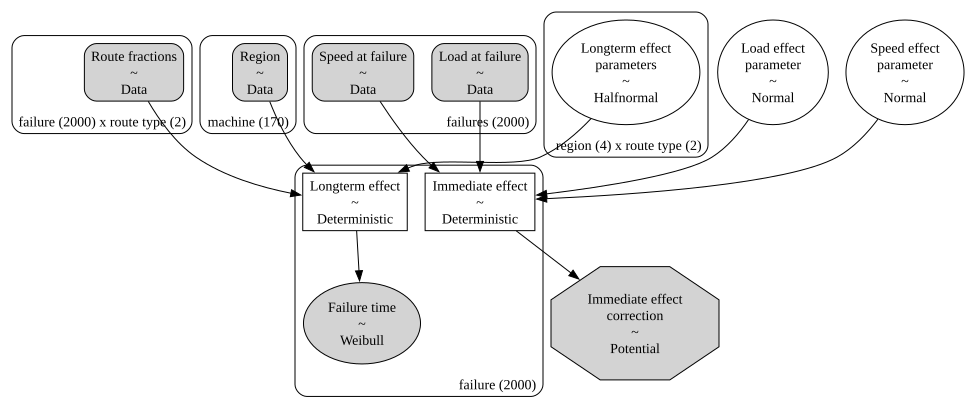

In [11]:
pm.model_to_graphviz(model=truck_brake_model)

In [12]:
trace = pm.sample(model=truck_brake_model, target_accept=0.95) # increased target_accept to reduce/avoid divergences

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Longterm effect
parameters, Speed effect
parameter, Load effect
parameter]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


In [13]:
# sampling in vanilla pymc is sufficiently fast, no need for nutpie for now
# import nutpie
# compiled = nutpie.compile_pymc_model(model=truck_brake_model, backend="jax", gradient_backend="jax")
# trace = nutpie.sample(compiled)

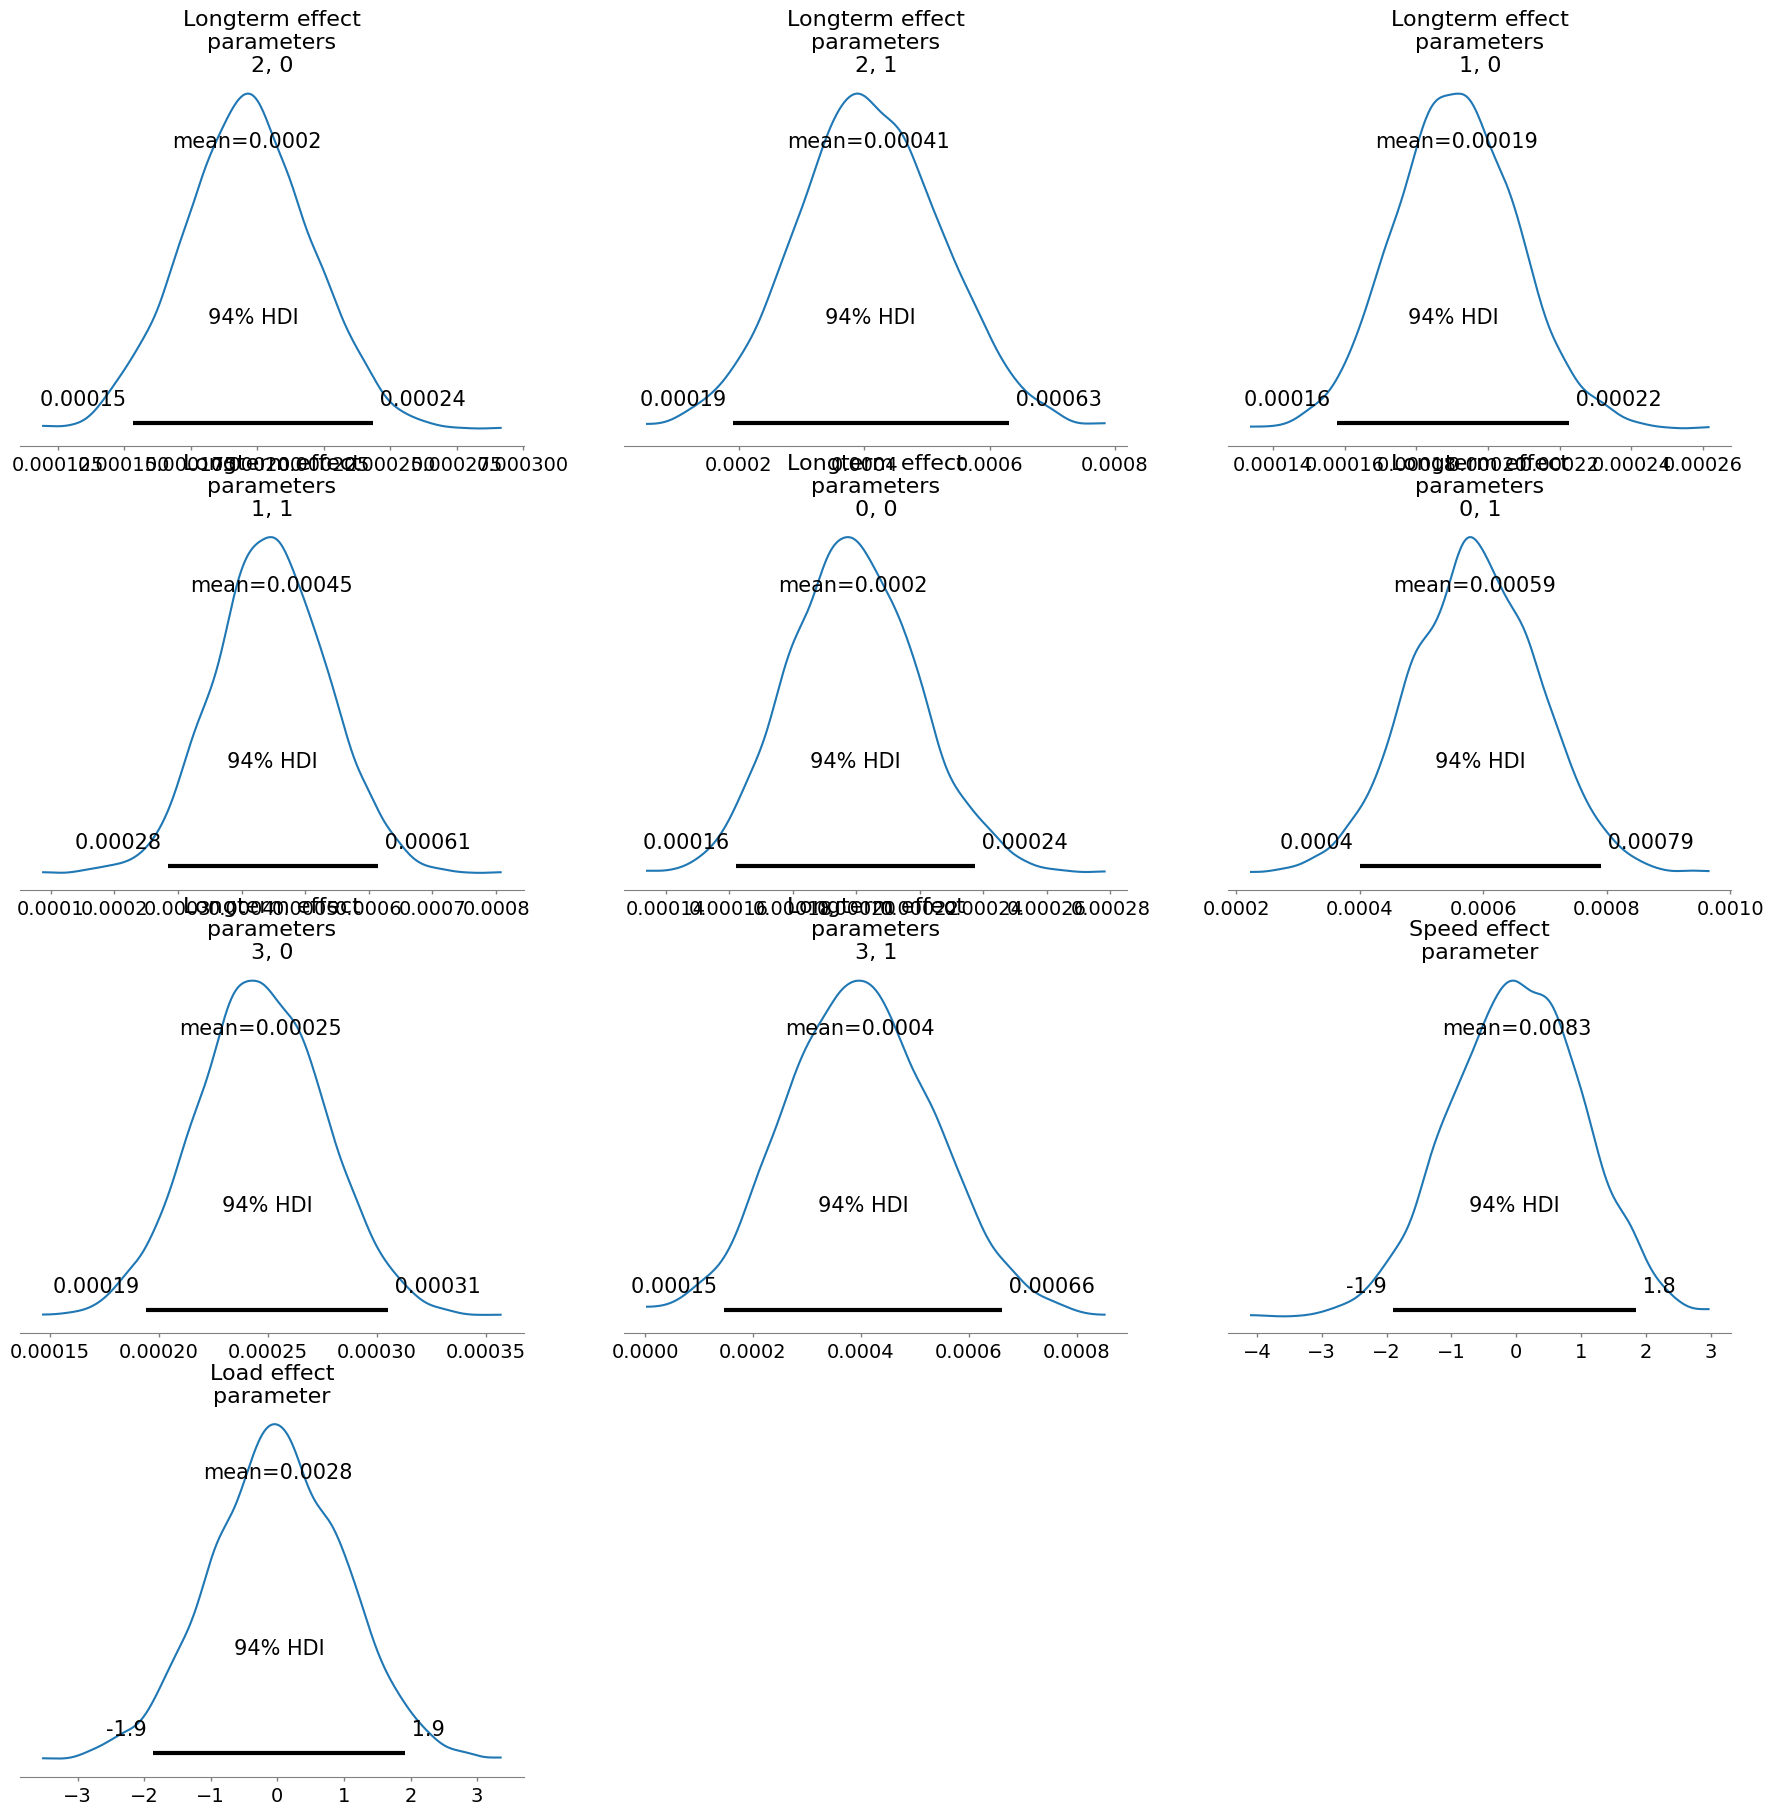

In [14]:
_ = pm.plot_posterior(trace, var_names=["Longterm effect\nparameters", "Speed effect\nparameter", "Load effect\nparameter"])

The posterior plot shows there is a good convergence. Note the broad distributions of speed and load effect parameters around zero. This means they have an insignificant effect (and can be left out for prediction).

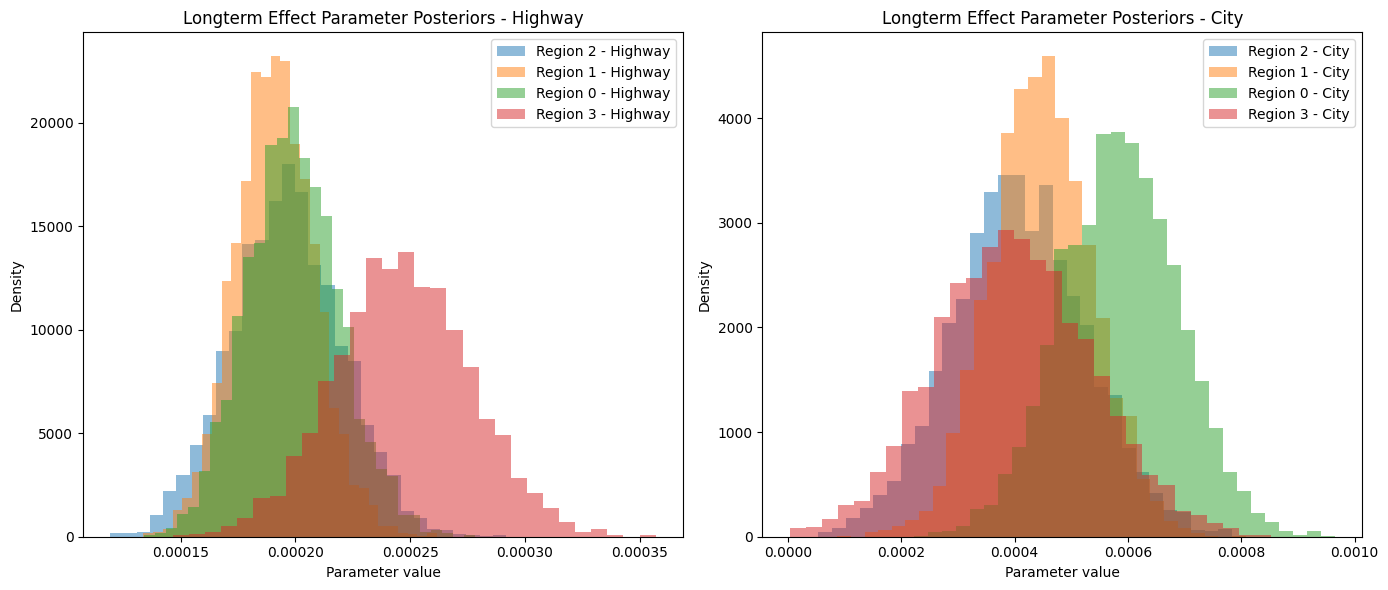

In [15]:
# overlay all longterm effect parameter posterior distributions in a single plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

posterior_samples = trace.posterior["Longterm effect\nparameters"].values
# reshape to (n_samples, n_regions, n_route_types)
n_samples = posterior_samples.shape[0] * posterior_samples.shape[1]
posterior_samples_flat = posterior_samples.reshape(n_samples, -1)

region_names = [f"Region {r}" for r in region_numbers]
route_names = ["Highway", "City"]

for j, ro in enumerate(route_names):
    for i, re in enumerate(region_numbers):
        label = f"{region_names[i]} - {ro}"
        ax[j].hist(posterior_samples[:, :, i, j].flatten(), bins=30, alpha=0.5, density=True, label=label)

ax[0].set_xlabel("Parameter value")
ax[0].set_ylabel("Density")
ax[0].set_title("Longterm Effect Parameter Posteriors - Highway")
ax[1].set_xlabel("Parameter value")
ax[1].set_ylabel("Density")
ax[1].set_title("Longterm Effect Parameter Posteriors - City")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

Clearly, there is a large difference between city and highway degradation, it is lower for city traffic. There are also regional differences but they are not very big, seemingly insignificant.

c:\Users\erik.hostens\AppData\Local\miniforge3\envs\Flambay_nutpie\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


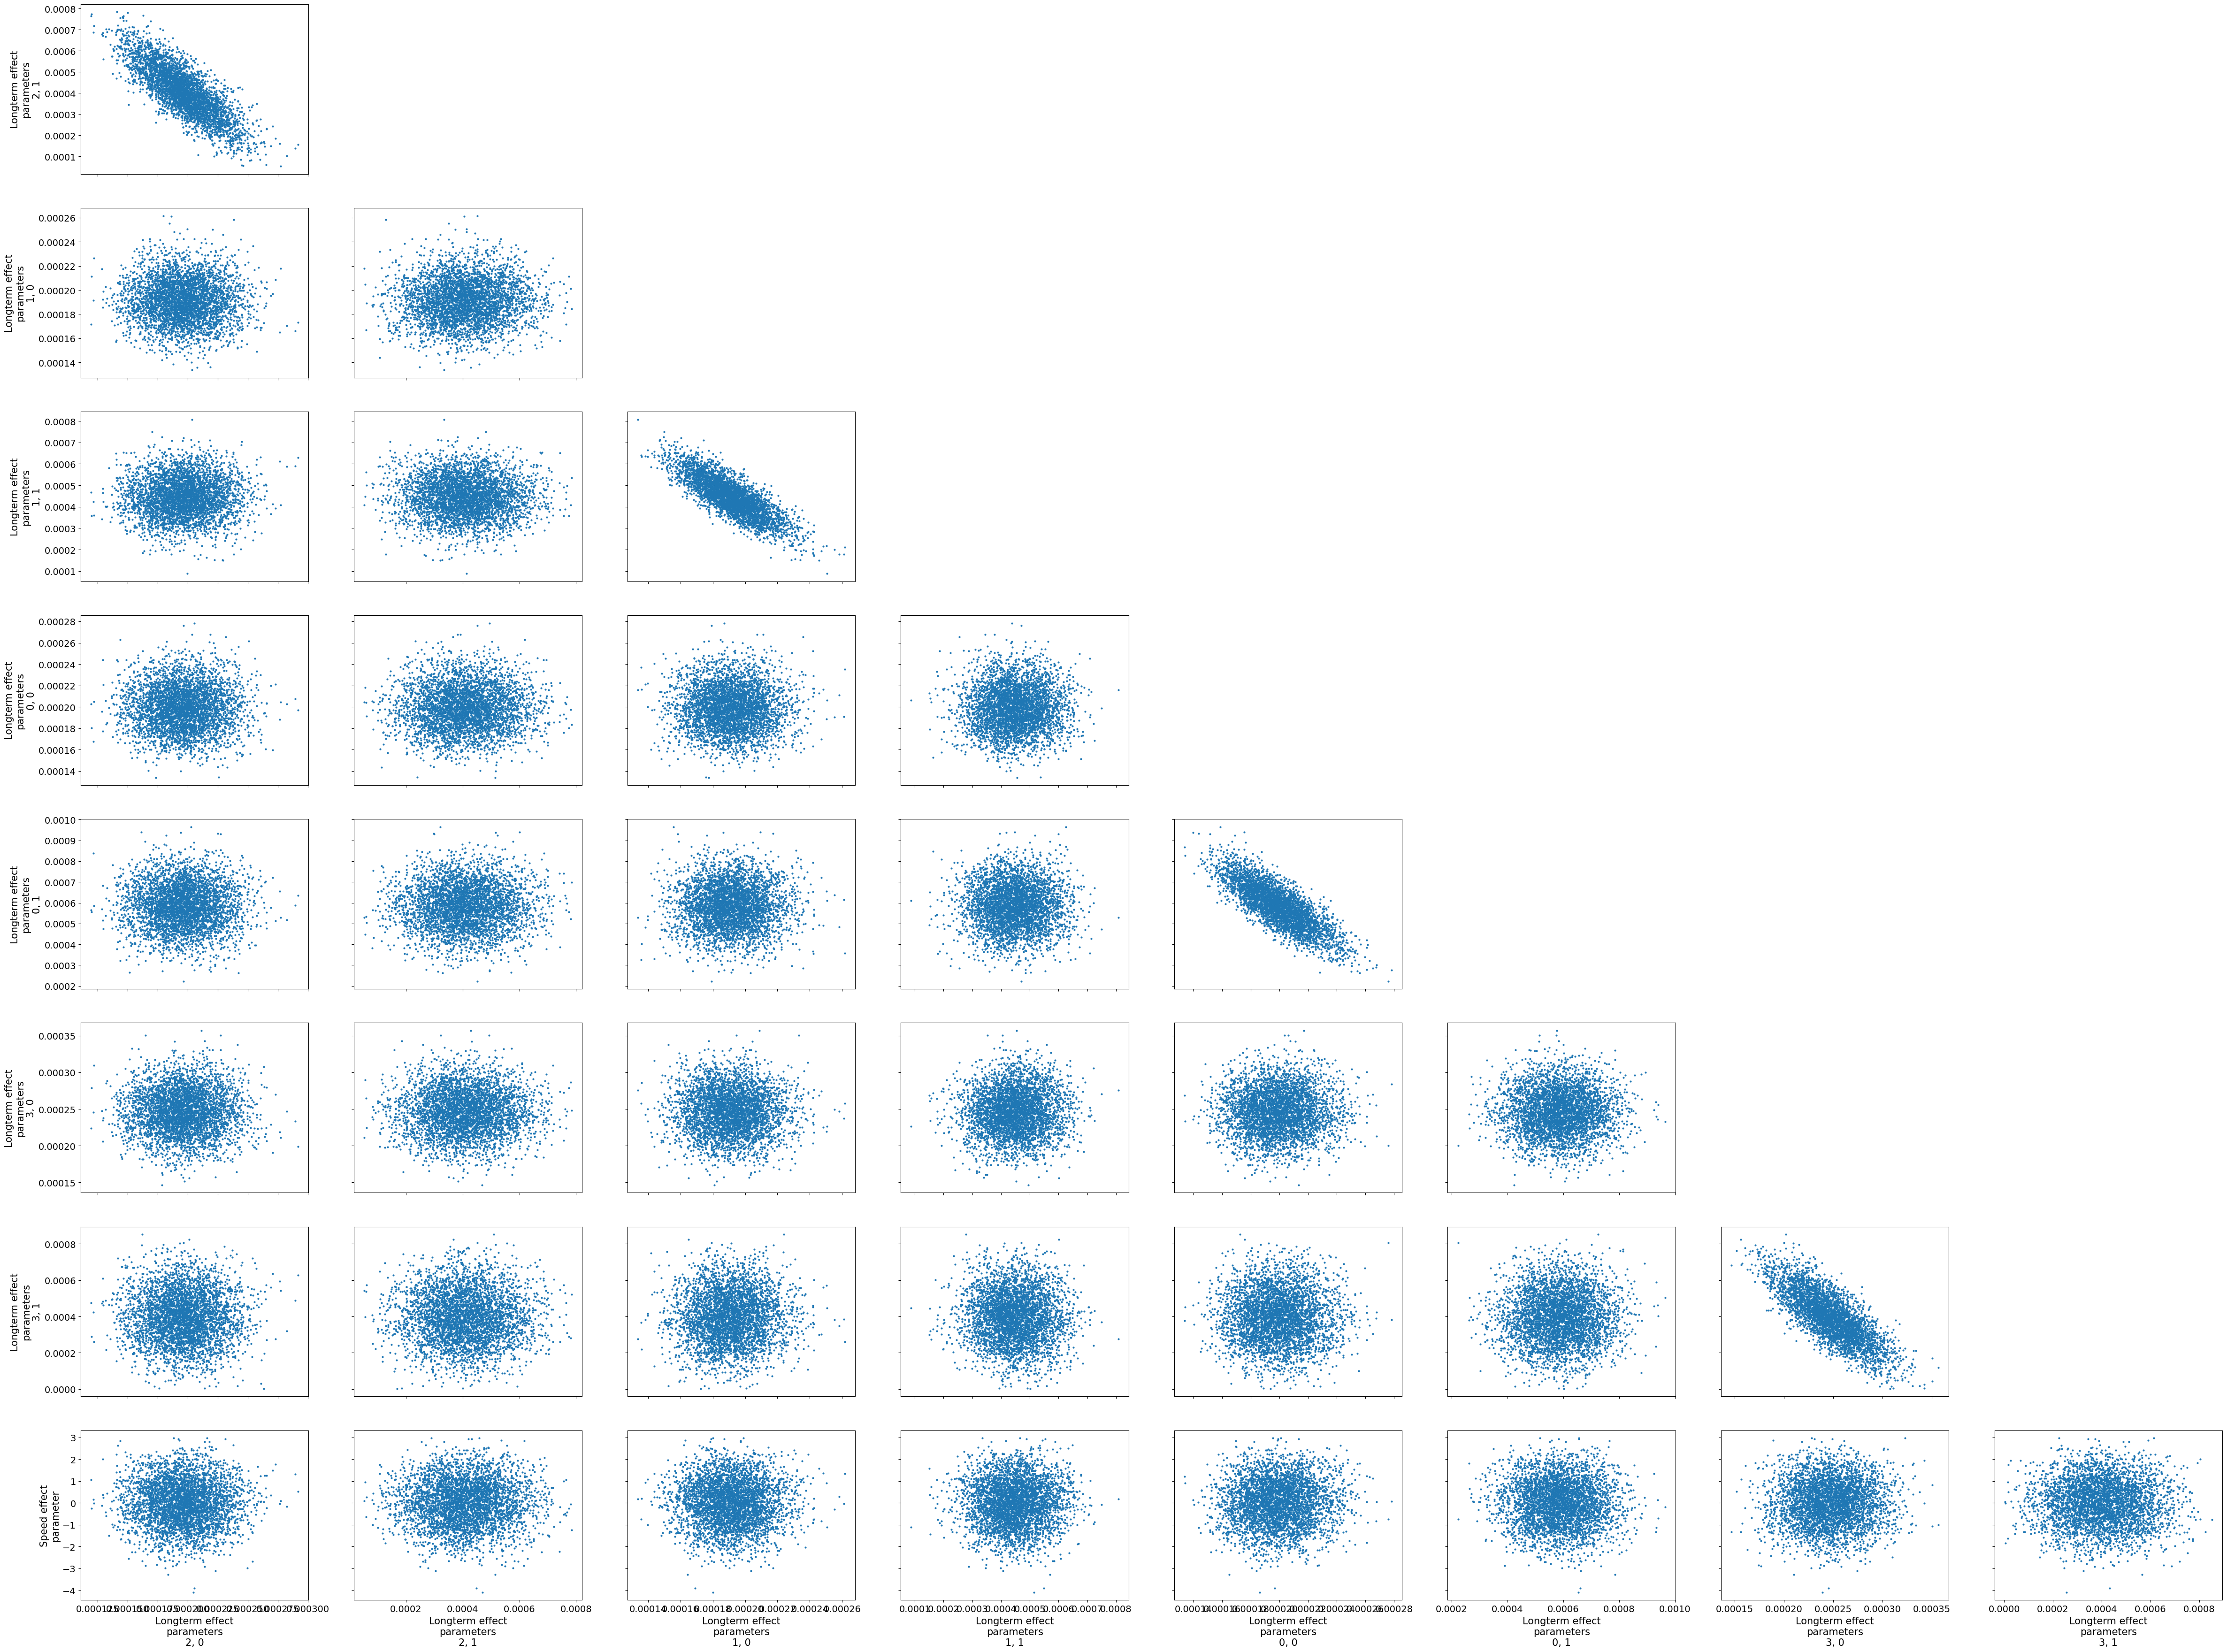

In [16]:
# are the posterior parameters correlated?
_ = az.plot_pair(trace, var_names=["Longterm effect\nparameters", "Speed effect\nparameter", "Load effect\nparameter"])

From the pairplot, we see a correlation between the longterm effects of city vs highway traffic, for each of the regions (not between regions). It makes sense that there is this negative correlation: they should balance one another because the resulting $a$ (speed of average hazard increase) is their weighted average. Their posteriors are so correlated because there is little variation in the ratio of highway vs city traffic.

The other posteriors are not correlated. That means the dataset probably contains all combinations of covariates sufficiently balanced (as in a full factorial DoE).

Let us redefine the model without the immediate effect, which then boils down to a Weibull distribution without the correction through a potential.

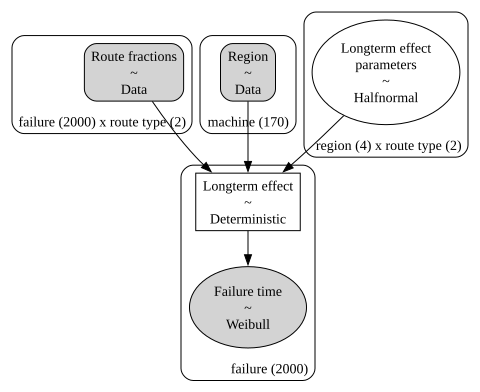

In [17]:
with pm.Model(coords=coords) as truck_brake_model2:
	# input data
	froute = pm.Data("Route fractions", failure_summary_df[["route_frac_HW", "route_frac_city"]], dims=("failure", "route type"))
	reg = pm.Data("Region", region, dims="machine")

	# parameter priors
	roregeff = pm.HalfNormal("Longterm effect\nparameters", sigma=np.pi/(2*failure_summary_df["failure_time"].mean()**2), dims=("region", "route type"))

	# covariates effect
	le = pm.Deterministic("Longterm effect", pm.math.sum(roregeff[reg[machine_idx], :] * froute, axis=1), dims="failure")

	# likelihood
	failure_time = pm.Weibull("Failure time", alpha=2.0, beta=pm.math.sqrt(2/le), observed=failure_summary_df["failure_time"], dims="failure")

pm.model_to_graphviz(model=truck_brake_model2)

In [18]:
# train again and retrieve parameter posteriors (mean and covariance)
trace2 = pm.sample(model=truck_brake_model2, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Longterm effect
parameters]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


In [19]:
# Get the longterm effect parameters posterior statistics (mean and covariance), to be used as priors for the prediction model
lt_samples = trace2.posterior["Longterm effect\nparameters"].to_dataframe()
lt_matrix = lt_samples["Longterm effect\nparameters"].unstack(["region", "route type"])
lt_mean = lt_matrix.mean()
lt_cov = lt_matrix.cov()
regions = lt_cov.index.get_level_values("region").to_numpy()
same_region = regions[:, None] == regions[None, :]
lt_cov = lt_cov.where(same_region, 0.0)
# reorder rows and columns of lt_mean and lt_cov to match lexicographical order of (region, route type)
lt_mean = lt_mean.sort_index()
lt_cov = lt_cov.sort_index().sort_index(axis=1)
lt_mean

region  route type
0       0             0.000199
        1             0.000588
1       0             0.000190
        1             0.000449
2       0             0.000197
        1             0.000404
3       0             0.000246
        1             0.000399
dtype: float64

In [20]:
lt_mean.to_numpy().reshape(4, 2)

array([[0.00019885, 0.00058826],
       [0.00019023, 0.00044941],
       [0.00019688, 0.00040389],
       [0.00024606, 0.00039856]])

## Predict failure times for test set

In [21]:
test_folder = pathlib.Path("..") / "assets" / "simulated_dataset" / "test"

test_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in test_folder.glob("*.csv")
}

list(test_dataframes.keys())

['tbm_failure_logs_combined_test',
 'tbm_ts_truck_brake_test',
 'tbm_ts_truck_tire_test',
 'tbm_ts_van_brake_test',
 'tbm_ts_van_tire_test']

In [22]:
truck_brake_test_df = test_dataframes['tbm_ts_truck_brake_test'].copy()
truck_brake_test_df.head()

,machine_id,time,car_type,region,route,route_ratio,speed,load,failure_occurred,failure_type
0,1,0.0,Trucks,1,0,5.134969,102.341757,0.759172,0,NaN
1,1,1.0,Trucks,1,0,5.134969,95.535084,0.385096,0,NaN
2,1,2.0,Trucks,1,0,5.134969,93.513556,0.857904,0,NaN
3,1,3.0,Trucks,1,0,5.134969,107.316614,0.644283,0,NaN
4,1,4.0,Trucks,1,0,5.134969,106.205191,0.608866,0,NaN


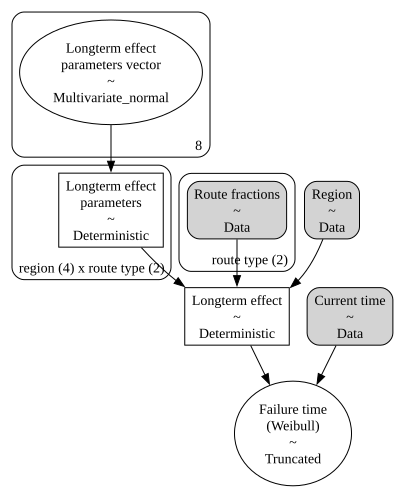

In [23]:
with pm.Model(coords=coords) as truck_brake_prediction_model:
	
	# parameter distribution
	roregeff_vec = pm.MvNormal("Longterm effect\nparameters vector", mu=lt_mean, cov=lt_cov)
	roregeff = pm.Deterministic("Longterm effect\nparameters", roregeff_vec.reshape((4, 2)), dims=("region", "route type"))

	# input data: set to dummy values for now, to be replaced with actual test data later (it just sets scalar vs vector shape)
	froute = pm.Data("Route fractions", np.array([0.5,0.5]), dims="route type")
	reg = pm.Data("Region", np.int16(0))
	current_time = pm.Data("Current time", 0.0)

	# covariates effect
	le = pm.Deterministic("Longterm effect", pm.math.sum(roregeff[reg, :] * froute))

	# likelihood
	failure_time = pm.Truncated("Failure time\n(Weibull)", pm.Weibull.dist(alpha=2.0, beta=pm.math.sqrt(2/le)), lower=current_time)

pm.model_to_graphviz(model=truck_brake_prediction_model)

In [24]:
def sample_rul(route_type, region, current_time, n_samples=1000):
    """
    Sample Remaining Useful Life (RUL) from the prediction model.
    
    Parameters
    ----------
    route_type : array-like of shape (2,)
        Route fractions [frac_HW, frac_city], must sum to 1.
    region : int
        Region index (0, 1, 2, or 3).
    current_time : float
        Current time (lower bound for truncated Weibull).
    n_samples : int
        Number of samples to draw.
    
    Returns
    -------
    rul_samples : numpy.ndarray
        Samples of RUL = failure_time - current_time.
    """
    with truck_brake_prediction_model:
        pm.set_data({
            "Route fractions": np.array(route_type, dtype=float),
            "Region": np.int16(region),
            "Current time": float(current_time),
        })
        prior_pred = pm.sample_prior_predictive(samples=n_samples) # use only the prior as we do not want to change the model parameters distributions
    
    failure_time_samples = prior_pred.prior["Failure time\n(Weibull)"].values.flatten()
    rul_samples = failure_time_samples - current_time
    return rul_samples

Sampling: [Failure time
(Weibull), Longterm effect
parameters vector]


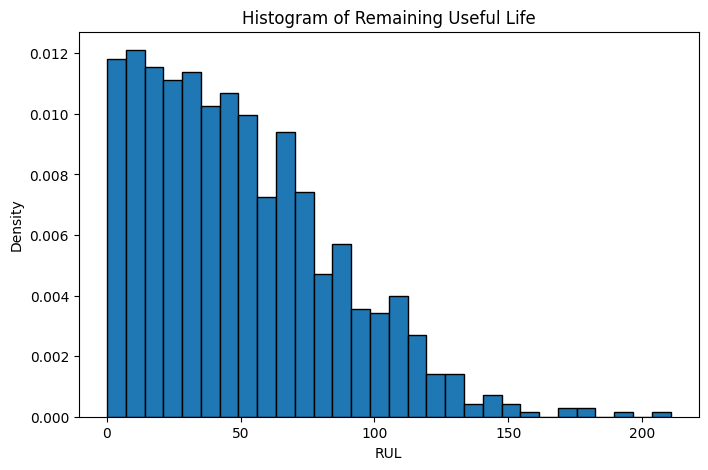

In [25]:
# example usage
rul = sample_rul(route_type=[0.8, 0.2], region=1, current_time=50.0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rul, bins=30, edgecolor="black", density=True)
ax.set_xlabel("RUL")
ax.set_ylabel("Density")
ax.set_title("Histogram of Remaining Useful Life")
plt.show()

In [48]:
# sort once (kept as a separate variable since it's used later too)
tb_test_sorted = truck_brake_test_df.sort_values(["machine_id", "time"]).reset_index(drop=True)

# segment id: resets right after each failure (failure row still belongs to previous segment)
seg_id = tb_test_sorted.groupby("machine_id")["failure_occurred"].shift(fill_value=0).groupby(tb_test_sorted["machine_id"]).cumsum()

# cumulative fractions of route==0 and route==1 since last failure (or start)
grp_keys = [tb_test_sorted["machine_id"], seg_id]
n_in_seg = tb_test_sorted.groupby(grp_keys).cumcount() + 1

cum_route0 = (tb_test_sorted["route"] == 0).groupby(grp_keys).cumsum()
cum_route1 = (tb_test_sorted["route"] == 1).groupby(grp_keys).cumsum()

frac_route0 = cum_route0 / n_in_seg
frac_route1 = cum_route1 / n_in_seg

# time until next failure in same machine (NaN if no future failure)
def _time_to_next_failure(g):
    t = g["time"].to_numpy()
    ft = t[g["failure_occurred"].to_numpy() == 1]
    out = np.full(len(g), np.nan, dtype=float)
    if ft.size:
        idx = np.searchsorted(ft, t, side="left")  # includes current failure => 0
        m = idx < ft.size
        out[m] = ft[idx[m]] - t[m]
    return pd.Series(out, index=g.index)

time_to_next_failure = tb_test_sorted.groupby("machine_id", group_keys=False).apply(_time_to_next_failure)

seg_start_time = tb_test_sorted.groupby(grp_keys)["time"].transform("min")
time_since_last_failure = tb_test_sorted["time"] - seg_start_time

tb_test_features = pd.DataFrame({
    "machine_id": tb_test_sorted["machine_id"].to_numpy(),
    "current_time": time_since_last_failure.to_numpy(),
    "RUL": time_to_next_failure.to_numpy(),
    "region": tb_test_sorted["region"].to_numpy(),
    "avg_frac_route_0": frac_route0.to_numpy(),
    "avg_frac_route_1": frac_route1.to_numpy(),
})


In [49]:
tb_test_features[tb_test_features["machine_id"] == 1]

,machine_id,current_time,RUL,region,avg_frac_route_0,avg_frac_route_1
0,1,0.0,91.0,1,1.000000,0.000000
1,1,1.0,90.0,1,1.000000,0.000000
2,1,2.0,89.0,1,1.000000,0.000000
3,1,3.0,88.0,1,1.000000,0.000000
4,1,4.0,87.0,1,1.000000,0.000000
...,...,...,...,...,...,...
995,1,18.0,NaN,1,0.894737,0.105263
996,1,19.0,NaN,1,0.900000,0.100000
997,1,20.0,NaN,1,0.904762,0.095238
998,1,21.0,NaN,1,0.909091,0.090909


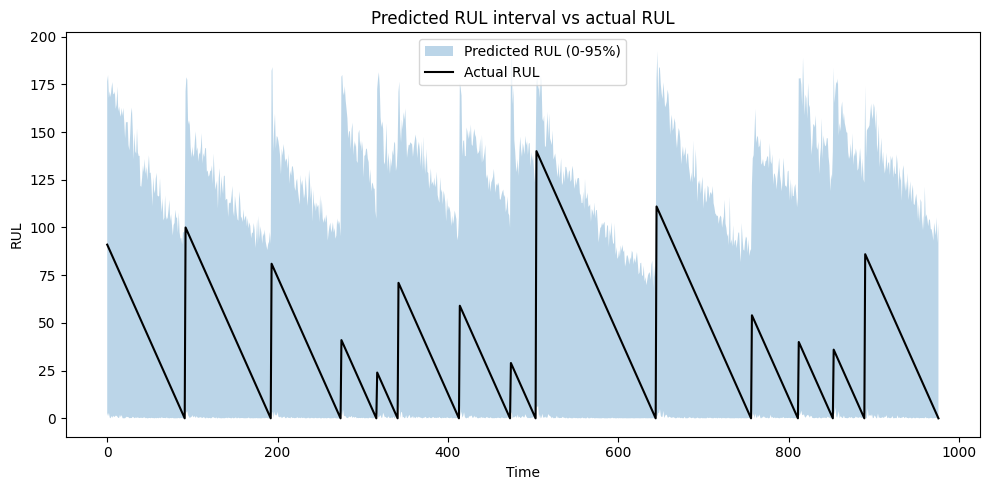

In [57]:
import logging
logger = logging.getLogger("pymc")
logger.setLevel(logging.ERROR) 

subset = tb_test_features.head(1000).copy()

q = np.array([
    np.percentile(
        sample_rul(
            route_type=[r.avg_frac_route_0, r.avg_frac_route_1],
            region=int(r.region),
            current_time=float(r.current_time),
            n_samples=500,
        ),
        [0, 95],
    )
    for r in subset.itertuples()
])

subset["rul_p0"] = q[:, 0]
subset["rul_p95"] = q[:, 1]

m = subset["RUL"].notna()
x = subset.index[m]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x, subset.loc[m, "rul_p0"], subset.loc[m, "rul_p95"], alpha=0.3, label="Predicted RUL (0-95%)")
ax.plot(x, subset.loc[m, "RUL"], color="black", lw=1.5, label="Actual RUL")
ax.set_xlabel("Time")
ax.set_ylabel("RUL")
ax.set_title("Predicted RUL interval vs actual RUL")
ax.legend()
plt.tight_layout()
plt.show()